# Election Poll Data Analysis

In this project, we'll look at the opinion poll data from the upcoming 2016 General Election. In the process, we'll try to answer the following questions:

- Who was being polled and what was their party affiliation?
- Did the poll results favour Clinton or Trump?
- How did voter sentiment change over time?
- Can we see an effect in the polls from the debates?

So let's get started with the imports!

In [1]:
#Data Analysis imports
import pandas as pd
from pandas import Series,DataFrame
import numpy as np
from datetime import datetime
import os

#Visualisation imports
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

We'll grab the poll data from _HuffPost Pollster_, and we'll use StringIO to prevent errors with pandas.

In [2]:
#The HuffPost Pollster API is defunct (the URL now 404s). This is a vendored snapshot
#from the Internet Archive (Wayback capture, 2017-01-08), stored under data/election/.
poll_csv = os.path.join('data', 'election', '2016-general-election-trump-vs-clinton.csv')

In [3]:
#Reading the csv object into a pandas dataframe
poll_df = pd.read_csv(poll_csv)

In [4]:
poll_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1674 entries, 0 to 1673
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Pollster                1674 non-null   str    
 1   Start Date              1674 non-null   str    
 2   End Date                1674 non-null   str    
 3   Entry Date/Time (ET)    1674 non-null   str    
 4   Number of Observations  1104 non-null   float64
 5   Population              1674 non-null   str    
 6   Mode                    1674 non-null   str    
 7   Trump                   1674 non-null   float64
 8   Clinton                 1674 non-null   float64
 9   Other                   1217 non-null   float64
 10  Undecided               1601 non-null   float64
 11  Pollster URL            1674 non-null   str    
 12  Source URL              1674 non-null   str    
 13  Partisan                1674 non-null   str    
 14  Affiliation             111 non-null    str    
 15

In [5]:
poll_df.head()

,Pollster,Start Date,End Date,Entry Date/Time (ET),Number of Observations,Population,Mode,Trump,Clinton,Other,Undecided,Pollster URL,Source URL,Partisan,Affiliation,Question Text,Question Iteration
0,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,940.0,Likely Voters,Internet,41.0,45.0,2.0,8.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1
1,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,NaN,Likely Voters - Democrat,Internet,6.0,89.0,0.0,4.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1
2,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,NaN,Likely Voters - Republican,Internet,82.0,7.0,2.0,6.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1
3,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,NaN,Likely Voters - independent,Internet,38.0,43.0,4.0,7.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1
4,IBD/TIPP,2016-11-04,2016-11-07,2016-11-08T12:10:06Z,1107.0,Likely Voters,Live Phone,43.0,41.0,4.0,5.0,http://elections.huffingtonpost.com/pollster/p...,http://www.investors.com/politics/ibd-tipp-pre...,Nonpartisan,NaN,NaN,1


### Who was being polled and what was their party affiliation?

Quickly visualising the affiliations of the different pollsters.

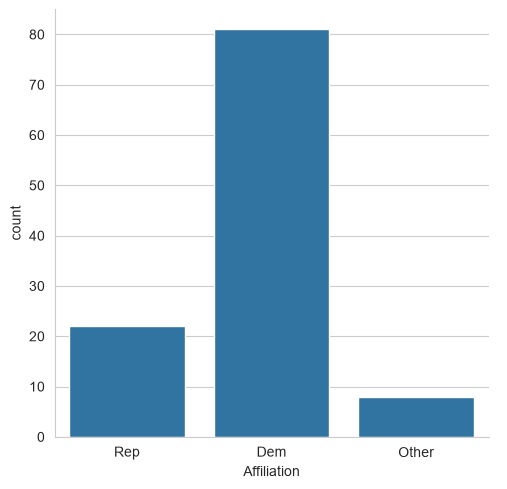

In [6]:
sns.catplot(x='Affiliation',data=poll_df,kind='count')

Most of the polls have no affiliation; though there's stronger affiliation for Democrats than for Republicans.

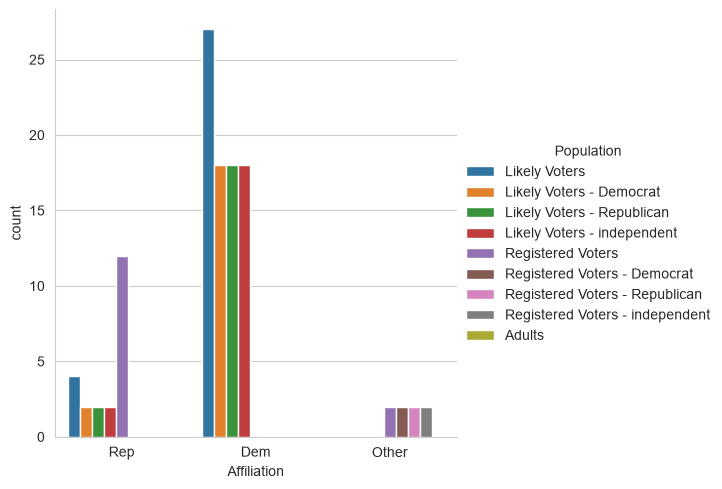

In [7]:
sns.catplot(x='Affiliation',data=poll_df,hue='Population',kind='count')

As there's a strong sample of registered voters that are not affiliated, we can hope that the poll data is a good representation of the upcoming elections.

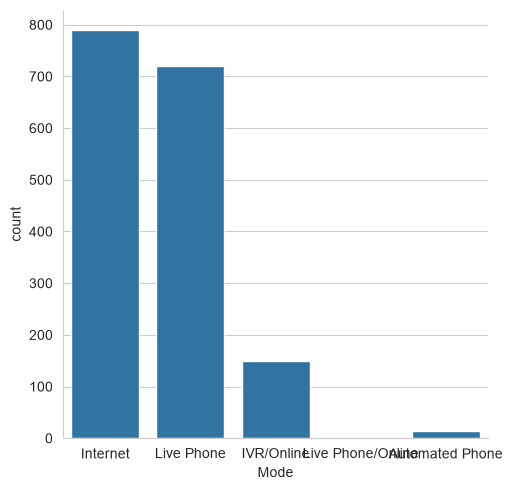

In [8]:
sns.catplot(x='Mode',data=poll_df,kind='count')

### Did the poll results favour Clinton or Trump?

In [9]:
avg = pd.DataFrame(poll_df.mean(numeric_only=True))

avg.drop(['Number of Observations','Question Iteration'],axis=0,inplace=True)

avg

,0
Trump,40.984468
Clinton,43.127240
Other,5.584224
Undecided,9.041224


In [10]:
std = pd.DataFrame(poll_df.std(numeric_only=True))

std.drop(['Number of Observations','Question Iteration'],axis=0,inplace=True)

std

,0
Trump,23.707190
Clinton,25.363371
Other,4.925900
Undecided,6.252763


<Axes: >

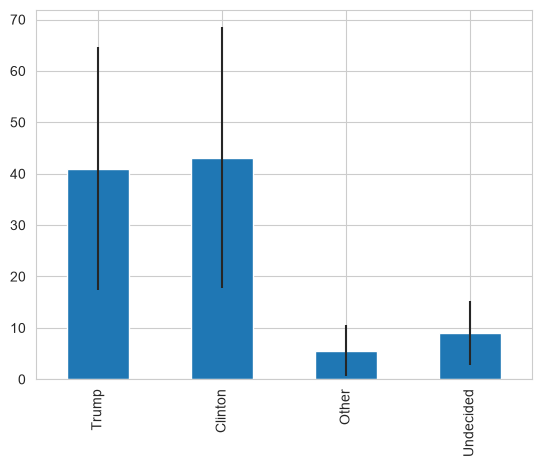

In [11]:
avg.plot(yerr=std,kind='bar',legend=False)

The race seems to be really close, with results in favour of Clinton with a higher standard deviation than for Trump.

In [12]:
poll_avg = pd.concat([avg,std],axis=1)

poll_avg.columns = ['Average','Stdev']

poll_avg

,Average,Stdev
Trump,40.984468,23.707190
Clinton,43.127240,25.363371
Other,5.584224,4.925900
Undecided,9.041224,6.252763


In [13]:
poll_df.head()

,Pollster,Start Date,End Date,Entry Date/Time (ET),Number of Observations,Population,Mode,Trump,Clinton,Other,Undecided,Pollster URL,Source URL,Partisan,Affiliation,Question Text,Question Iteration
0,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,940.0,Likely Voters,Internet,41.0,45.0,2.0,8.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1
1,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,NaN,Likely Voters - Democrat,Internet,6.0,89.0,0.0,4.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1
2,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,NaN,Likely Voters - Republican,Internet,82.0,7.0,2.0,6.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1
3,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,NaN,Likely Voters - independent,Internet,38.0,43.0,4.0,7.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1
4,IBD/TIPP,2016-11-04,2016-11-07,2016-11-08T12:10:06Z,1107.0,Likely Voters,Live Phone,43.0,41.0,4.0,5.0,http://elections.huffingtonpost.com/pollster/p...,http://www.investors.com/politics/ibd-tipp-pre...,Nonpartisan,NaN,NaN,1


### How did voter sentiment change over time?

In [14]:
poll_df['Difference'] = (poll_df.Clinton - poll_df.Trump)/100

poll_df.head()

,Pollster,Start Date,End Date,Entry Date/Time (ET),Number of Observations,Population,Mode,Trump,Clinton,Other,Undecided,Pollster URL,Source URL,Partisan,Affiliation,Question Text,Question Iteration,Difference
0,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,940.0,Likely Voters,Internet,41.0,45.0,2.0,8.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1,0.04
1,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,NaN,Likely Voters - Democrat,Internet,6.0,89.0,0.0,4.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1,0.83
2,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,NaN,Likely Voters - Republican,Internet,82.0,7.0,2.0,6.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1,-0.75
3,Insights West,2016-11-04,2016-11-07,2016-11-08T12:16:30Z,NaN,Likely Voters - independent,Internet,38.0,43.0,4.0,7.0,http://elections.huffingtonpost.com/pollster/p...,http://www.insightswest.com/news/clinton-is-ah...,Nonpartisan,NaN,"As you may know, there will be a presidential ...",1,0.05
4,IBD/TIPP,2016-11-04,2016-11-07,2016-11-08T12:10:06Z,1107.0,Likely Voters,Live Phone,43.0,41.0,4.0,5.0,http://elections.huffingtonpost.com/pollster/p...,http://www.investors.com/politics/ibd-tipp-pre...,Nonpartisan,NaN,NaN,1,-0.02


The difference is Clinton - Trump. So a positive difference indicates a Clinton lead, and a negative difference indicates a Trump lead.

In [15]:
#Grouping polls by the start data
poll_df = poll_df.groupby(['Start Date'],as_index=False).mean(numeric_only=True)

poll_df.tail()

,Start Date,Number of Observations,Trump,Clinton,Other,Undecided,Question Iteration,Difference
262,2016-10-31,30546.600000,45.200000,48.600000,3.333333,3.333333,1.400000,0.034000
263,2016-11-01,808.700000,45.045455,43.772727,4.000000,3.809524,1.363636,-0.012727
264,2016-11-02,1748.400000,40.823529,42.411765,6.941176,6.823529,1.470588,0.015882
265,2016-11-03,1386.250000,43.714286,46.785714,3.500000,4.142857,1.500000,0.030714
266,2016-11-04,1295.722222,43.666667,44.125000,4.541667,4.800000,1.250000,0.004583


<Axes: xlabel='Start Date'>

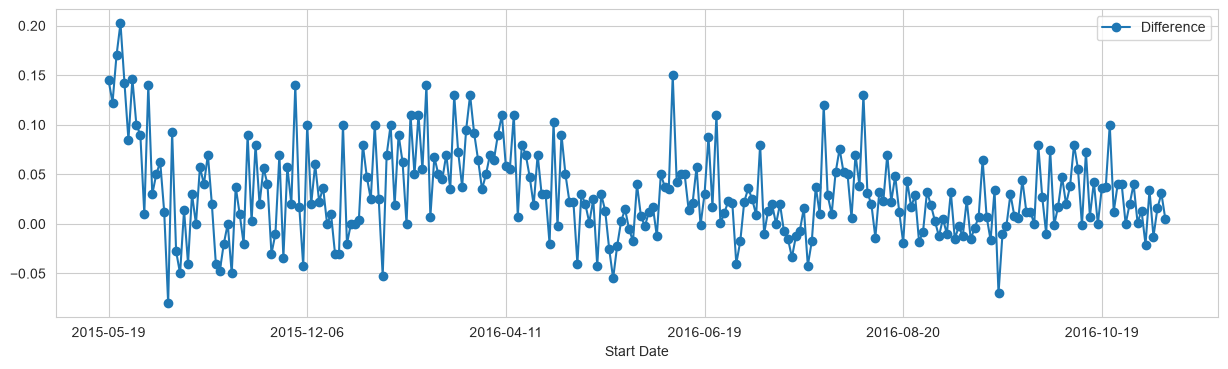

In [16]:
poll_df.plot('Start Date','Difference',figsize=(15,4),marker='o',linestyle='-')

The visualisation indicates that Trump has a slight lead in the polls, on average. __Keep in mind that this is without accounting for the weights of different polls, demographics, and affiliations of the population polled.__ 

The latest start date in our grouped dataframe is 27-September-2016.

### Can we see an effect in the polls from the debates?

Another interesting thing that we can look into, is what happened on the days leading up to the first debate, and afterwards. We know that the debate was on 26-September-2016, so we'll plot the trends for the month of September.

To get a list of indices for September, we'll loop through the dataframe, and append any row with a September start date to the list.

In [17]:
#Find the row indices for September 2016 polls, to zoom the plot into the debate window.
sept_idx = [i for i, date in enumerate(poll_df['Start Date']) if str(date)[0:7] == '2016-09']
first_sept, last_sept = min(sept_idx), max(sept_idx)
print("First September index:", first_sept)
print("Last September index:", last_sept)

#Index of the first poll on/after the first presidential debate (2016-09-26).
debate_idx = next((i for i, d in enumerate(poll_df['Start Date']) if str(d) >= '2016-09-26'), last_sept)
print("First-debate index:", debate_idx)

First September index: 210
Last September index: 232
First-debate index: 228


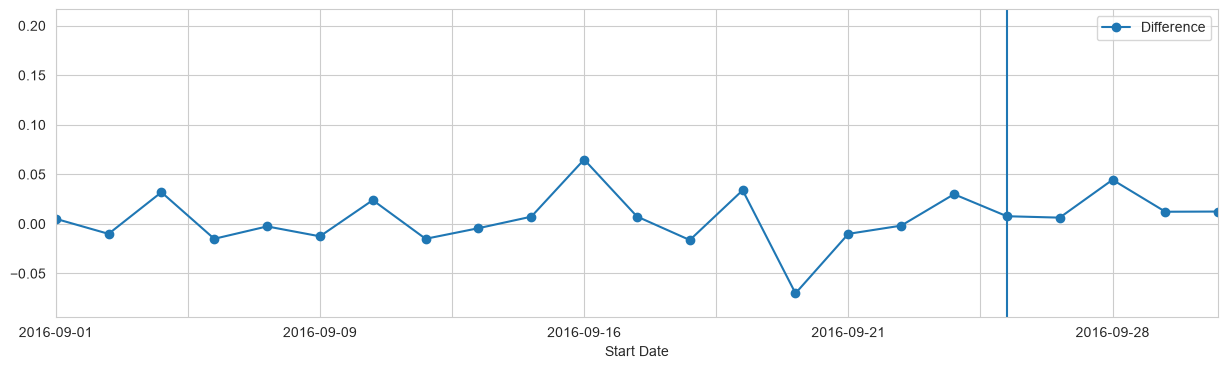

In [18]:
poll_df.plot('Start Date','Difference',figsize=(15,4),marker='o',linestyle='-',xlim=(first_sept, last_sept))

#Vertical line for the first presidential debate (2016-09-26)
plt.axvline(x=debate_idx)

And what it looks like, is that the sentiment shifted slightly in favour of Trump, after the debate. Again, it's important to keep in mind that we're dealing with averages.